## 2D CSA

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import bisect
from matplotlib.lines import Line2D

In [2]:
np.random.seed(0)

### Data Simulation 
simulating the data according to different classes

In [3]:
def simulate_class_data(n, ratio_A, ratio_B, ratio_C, ratio_D):
    """
    Simulates 4 scenarios of class data
        - Class A: P1 is good and P2 is bad
        - Class B: P1 is bad and P2 is good 
        - Class C: Both P1 and P2 are good
        - Class D: Both P1 and P2 are bad

    scores = 1-p (so 0.1 is good and 0.8 is bad)
    """

    # Class A: P1 is good (0.1) and P2 is bad (0.7)
    n_A = int(n * ratio_A)
    A = np.abs(np.random.multivariate_normal([0.1, 0.7], [[0.01, 0], [0, 0.01]], n_A))

    # Class B: P1 is bad (0.7) and P2 is good (0.1)
    n_B = int(n * ratio_B)
    B = np.abs(np.random.multivariate_normal([0.7, 0.1], [[0.01, 0], [0, 0.01]], n_B))  

    # Class C: Both P1 and P2 are good (0.1)
    n_C = int(n * ratio_C)
    C = np.abs(np.random.multivariate_normal([0.1, 0.1], [[0.01, 0], [0, 0.01]], n_C))  

    # Class D: Both P1 and P2 are bad (0.7)
    n_D = int(n * ratio_D)
    D = np.abs(np.random.multivariate_normal([0.7, 0.7], [[0.01, 0], [0, 0.01]], n_D))  

    # Combining all the classes into one dataset
    all_scores = np.vstack((A, B, C, D))
    all_scores = np.clip(all_scores, 0, 1)  # Clipping to make sure that all scores are between 0 and 1

    # Returning the scores and labels
    labels = np.array(['A']*n_A + ['B']*n_B + ['C']*n_C + ['D']*n_D)
    return all_scores, labels

### Phage-Wise Data Splitting 

In [4]:
def split_calibration_data(scores, labels, split_ratio):
    """
    Splits the calibration data into two sets based on the split ratio.
    """
 
    n = len(scores)      
    indices = np.arange(n)     # 
    np.random.shuffle(indices)  

    limit = int(n * split_ratio)     # Number of samples for the shape set
    shape_set = scores[indices[:limit]]
    shape_set_labels = labels[indices[:limit]]
    size_set = scores[indices[limit:]]
    size_set_labels = labels[indices[limit:]]
    return shape_set, size_set, shape_set_labels, size_set_labels

### Discovering the Shape

**$\pi / 2$ --> $2 \pi$???** 

In [5]:
def shape_discovery(shape_set_scores, alpha, M):
 
    # Directions (Angles 0 to 90 degrees)
    angles = np.linspace(0, np.pi/2, M)
    u_directions = np.vstack([np.cos(angles), np.sin(angles)]).T

    # Projecting the scores from the 'shape' sets onto the directions
    projections = shape_set_scores @ u_directions.T
    
    # We are searcging for the largest beta such that the intersection of half-planes defined by the quantiles has coverage >= 1-alpha
    # We will search from small beta (wide region) to large beta (tight region)
    beta_candidates = np.linspace(alpha/M, alpha, 500)
    
    beta_star = alpha/M     # Default to conservative Bonferroni
    q_tilde = np.quantile(projections, 1 - beta_star, axis=0)

    for beta in beta_candidates:
        q_beta = np.quantile(projections, 1 - beta, axis=0)
        
        if np.mean(np.all(projections <= q_beta, axis=1)) >= 1 - alpha:    # Checking if the coverage condition is satisfied
            beta_star = beta  
            q_tilde = q_beta
        else:
            break 

    return u_directions, q_tilde, beta_star

### Scaling

In [6]:
def size_scaling(size_set_scores, u_directions, q_tilde, alpha):
    projections = size_set_scores @ u_directions.T
    tau_scores = np.max(projections / (q_tilde + 1e-12), axis=1)
    n2 = len(tau_scores)
    sorted_tau = np.sort(tau_scores)
    idx = int(np.ceil((n2 + 1) * (1 - alpha))) - 1
    t_hat = sorted_tau[np.clip(idx, 0, n2 - 1)]
    return t_hat, tau_scores

## Testing Function 
getting the prediction set

In [7]:
def get_prediction_set(candidate_host_scores, u_directions, q_tilde, t_hat):
    """
    Tests each candidate host. Returns indices of those accepted.
    """
    # Max-ratio check for all candidates at once
    projs = candidate_host_scores @ u_directions.T
    ratios = np.max(projs / (q_tilde + 1e-12), axis=1)
    return np.where(ratios <= t_hat)[0]

### Visualizing

In [8]:
def plot_4_host_inference(raw_scores, labels, u_directions, q_tilde, t_hat, mystery_scores, accepted_indices, alpha):
    plt.figure(figsize=(10, 8))
    
    # 1. Plotting the 4 clusters of calibration data
    colors = {'A': 'tab:red', 'B': 'tab:orange', 'C': 'tab:green', 'D': 'tab:gray'}
    for cls in ['A', 'B', 'C', 'D']:
        mask = labels == cls
        plt.scatter(raw_scores[mask, 0], raw_scores[mask, 1], 
                    c=colors[cls], label=f"Calibration Phages (Host {cls})", s=20)

    # 2. Draw the Final Calibrated Region (The Filter)
    x_range = np.linspace(0, 1, 100)
    y_range = np.linspace(0, 1, 100)
    X, Y = np.meshgrid(x_range, y_range)
    grid = np.vstack([X.ravel(), Y.ravel()]).T
    
    q_final = q_tilde * t_hat
    inside_final = np.all((u_directions @ grid.T).T <= q_final, axis=1).reshape(X.shape)
    
    plt.contourf(X, Y, inside_final, levels=[0.5, 1], colors='blue', alpha=0.1)
    # Removed 'label' from contour to fix UserWarning
    plt.contour(X, Y, inside_final, levels=[0.5], colors='blue', linewidths=3)

    # 3. Plot the 4 Candidates for the Mystery Phage
    host_names = ['Host A', 'Host B', 'Host C', 'Host D']
    for i, score in enumerate(mystery_scores):
        is_accepted = i in accepted_indices
        marker = 'P' if is_accepted else 'X'
        color = 'darkblue' if is_accepted else 'black'
        
        plt.scatter(score[0], score[1], color=color, marker=marker, s=150, edgecolors='white', zorder=5)
        plt.text(score[0] + 0.02, score[1] + 0.02, f"Test: {host_names[i]}", 
                 fontweight='bold' if is_accepted else 'normal', fontsize=10)

    # DYNAMIC TITLE: Uses the alpha passed into the function
    confidence_level = int((1 - alpha) * 100)
    plt.title(f"CSA 4-Host Inference\n(Blue Shaded Area = {confidence_level}% Confidence Set)")
    
    plt.xlabel("Model 1 Error (P1)")
    plt.ylabel("Model 2 Error (P2)")
    
    # Custom Legend to include the Acceptance Region Line properly
    handles, labels_legend = plt.gca().get_legend_handles_labels()
    handles.append(Line2D([0], [0], color='blue', lw=3))
    labels_legend.append("Acceptance Region")
    
    plt.legend(handles=handles, labels=labels_legend, loc='upper right')
    plt.grid(alpha=0.3)
    plt.show()

execution

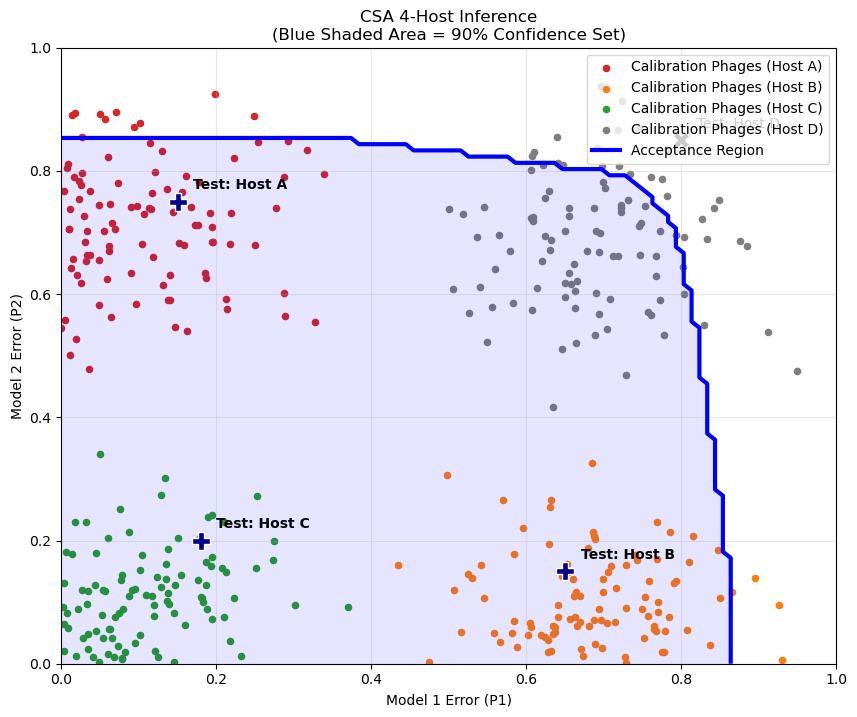

Prediction Set: ['Host A', 'Host B', 'Host C']


In [9]:
alpha = 0.1
M = 100

# 1. Setup Calibration Data
raw_scores, labels = simulate_class_data(n=400, ratio_A=0.25, ratio_B=0.25, ratio_C=0.25, ratio_D=0.25)
S1, S2, L1, L2 = split_calibration_data(raw_scores, labels, 0.5)

# 2. Run Calibration
u_dirs, q_template, b_star = shape_discovery(S1, alpha, M)
t_val, _ = size_scaling(S2, u_dirs, q_template, alpha)

# 3. INFERENCE: Test a Mystery Phage whose TRUE host is B
# We generate scores for how this phage looks against the 4 possible hosts
mystery_phage_test_scores = np.array([
    [0.15, 0.75], # Against Host A (P1 good, P2 bad)
    [0.65, 0.15], # Against Host B (THE TRUTH - P1 bad, P2 good)
    [0.18, 0.20], # Against Host C (Both good)
    [0.80, 0.85]  # Against Host D (Both bad)
])

# Get the Prediction Set
prediction_set = get_prediction_set(mystery_phage_test_scores, u_dirs, q_template, t_val)

# 4. Visualize the Result
plot_4_host_inference(raw_scores, labels, u_dirs, q_template, t_val, mystery_phage_test_scores, prediction_set, alpha)

print(f"Prediction Set: {[ ['Host A', 'Host B', 'Host C', 'Host D'][i] for i in prediction_set]}")

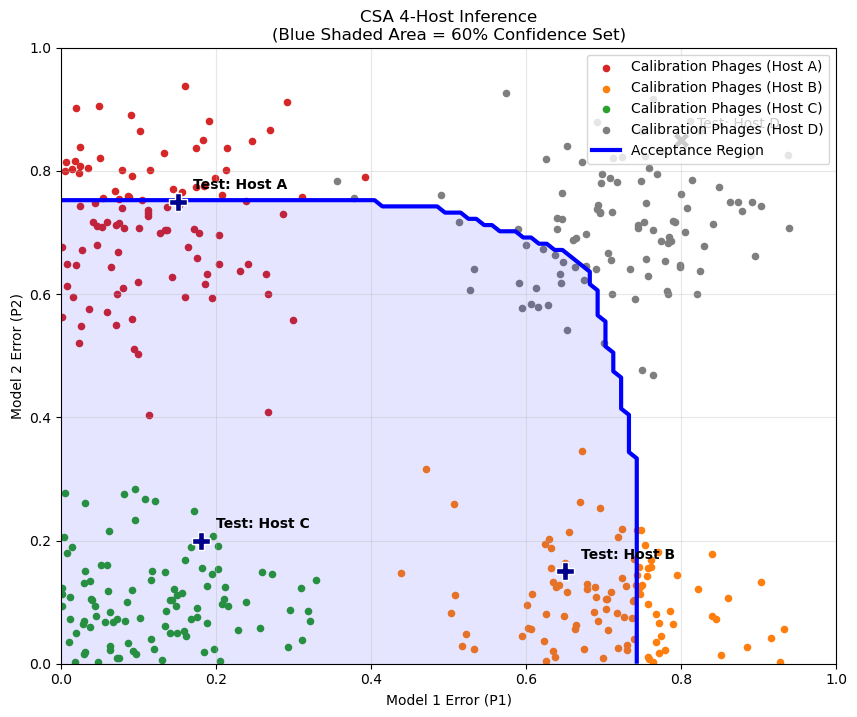

Prediction Set: ['Host A', 'Host B', 'Host C']


In [10]:
alpha = 0.40
M = 100

# 1. Setup Calibration Data
raw_scores, labels = simulate_class_data(n=400, ratio_A=0.25, ratio_B=0.25, ratio_C=0.25, ratio_D=0.25)
S1, S2, L1, L2 = split_calibration_data(raw_scores, labels, 0.5)

# 2. Run Calibration
u_dirs, q_template, b_star = shape_discovery(S1, alpha, M)
t_val, _ = size_scaling(S2, u_dirs, q_template, alpha)

# 3. INFERENCE: Test a Mystery Phage whose TRUE host is B
# We generate scores for how this phage looks against the 4 possible hosts
mystery_phage_test_scores = np.array([
    [0.15, 0.75], # Against Host A (P1 good, P2 bad)
    [0.65, 0.15], # Against Host B (THE TRUTH - P1 bad, P2 good)
    [0.18, 0.20], # Against Host C (Both good)
    [0.80, 0.85]  # Against Host D (Both bad)
])

# Get the Prediction Set
prediction_set = get_prediction_set(mystery_phage_test_scores, u_dirs, q_template, t_val)

# 4. Visualize the Result
plot_4_host_inference(raw_scores, labels, u_dirs, q_template, t_val, mystery_phage_test_scores, prediction_set, alpha)

print(f"Prediction Set: {[ ['Host A', 'Host B', 'Host C', 'Host D'][i] for i in prediction_set]}")